In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("../data/energy_dataset.csv")
df.head()

,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
0,274,378,272,19,4.702751,0.530007,4,1
1,339,359,175,18,4.972581,0.817926,1,0
2,314,297,140,17,3.809120,0.644334,2,0
3,332,448,170,17,5.141293,0.680344,4,0
4,313,342,260,28,4.652013,0.756585,2,1


In [3]:
X = df.drop(columns=["energy_class"])
y = df["energy_class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4000, 7) Test: (1000, 7)


In [5]:
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"=== {title} ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1-macro     : {f1_macro:.4f}")
    print(f"F1-weighted  : {f1_weighted:.4f}\n")

    print("Classification report (par classe):")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))    
    disp.plot(values_format="d")
    plt.title(f"Matrice de confusion — {title}")
    plt.show()

    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}


=== SVM Linéaire (C=1) ===
Accuracy     : 0.8690
F1-macro     : 0.7680
F1-weighted  : 0.8679

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       569
           1       0.80      0.87      0.83       371
           2       0.63      0.48      0.55        60

    accuracy                           0.87      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.87      0.87      0.87      1000



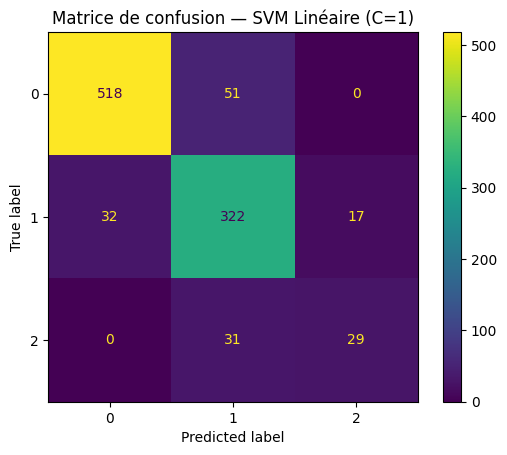

In [6]:
svm_linear = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])

svm_linear.fit(X_train, y_train)
res_linear = evaluate_model(svm_linear, X_test, y_test, title="SVM Linéaire (C=1)")


In [7]:
C_values = [0.01, 0.1, 1, 10, 100]
results_C = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=C))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_C.append({
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

pd.DataFrame(results_C).sort_values("f1_macro", ascending=False)


,C,accuracy,f1_macro
2,1.00,0.869,0.767988
4,100.00,0.869,0.767988
3,10.00,0.869,0.767988
1,0.10,0.868,0.743713
0,0.01,0.856,0.582932


Best params (Linear): {'svc__C': 10}
Best CV f1_macro: 0.7759802863274278
=== Best SVM Linéaire (GridSearch C) ===
Accuracy     : 0.8690
F1-macro     : 0.7680
F1-weighted  : 0.8679

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       569
           1       0.80      0.87      0.83       371
           2       0.63      0.48      0.55        60

    accuracy                           0.87      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.87      0.87      0.87      1000



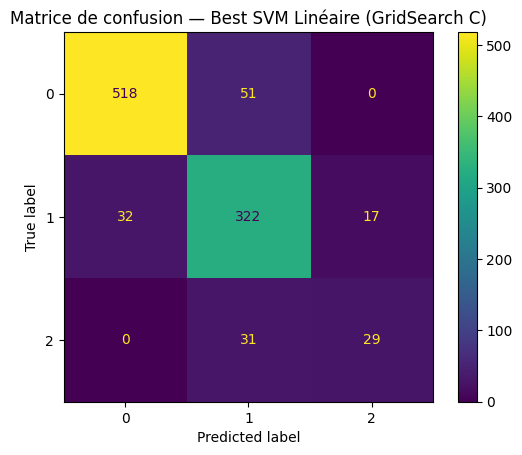

In [13]:
param_grid_linear = {"svc__C": [0.01, 0.1, 1, 10, 100]}

grid_linear = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear"))]),
    param_grid=param_grid_linear,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_linear.fit(X_train, y_train)

print("Best params (Linear):", grid_linear.best_params_)
print("Best CV f1_macro:", grid_linear.best_score_)

best_linear = grid_linear.best_estimator_
res_best_linear = evaluate_model(best_linear, X_test, y_test, "Best SVM Linéaire (GridSearch C)")


In [ ]:
svm_rbf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_rbf.fit(X_train, y_train)
res_rbf = evaluate_model(svm_rbf, X_test, y_test, title="SVM RBF (C=1, gamma=scale)")


In [22]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

results = []

for C in C_values:
    for gamma in gamma_values:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=C, gamma=gamma))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro")
        })

df_results = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
df_results

,C,gamma,accuracy,f1_macro
20,100.00,0.001,0.870,0.764406
22,100.00,0.100,0.852,0.747137
17,10.00,0.100,0.861,0.738039
21,100.00,0.010,0.858,0.734615
12,1.00,0.100,0.864,0.730472
16,10.00,0.010,0.859,0.727866
18,10.00,1.000,0.810,0.676294
23,100.00,1.000,0.810,0.676294
13,1.00,1.000,0.839,0.645736
11,1.00,0.010,0.856,0.582932


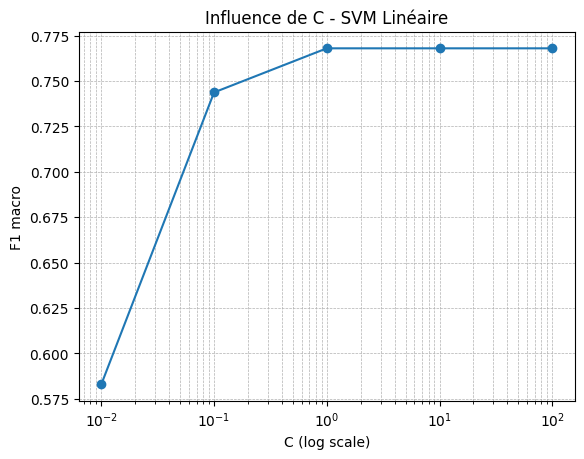

In [24]:
# -------------------------
# 1) Courbe influence de C (LINEAR)
# -------------------------
C_values = [0.01, 0.1, 1, 10, 100]
results_linear = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=C))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_linear.append({
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

df_linear = pd.DataFrame(results_linear).sort_values("C")

# Plot Linear
plt.figure()
plt.plot(df_linear["C"], df_linear["f1_macro"], marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("F1 macro")
plt.title("Influence de C - SVM Linéaire")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Meilleurs params (RBF): {'svc__C': 100, 'svc__gamma': 0.01}
Meilleur score CV (f1_macro): 0.7713786108383068
=== Best SVM RBF (GridSearch C+gamma) ===
Accuracy     : 0.8580
F1-macro     : 0.7346
F1-weighted  : 0.8553

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       569
           1       0.78      0.87      0.82       371
           2       0.59      0.38      0.46        60

    accuracy                           0.86      1000
   macro avg       0.77      0.72      0.73      1000
weighted avg       0.86      0.86      0.86      1000



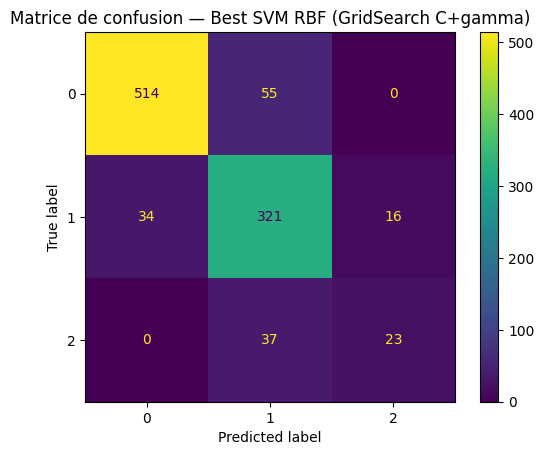

In [11]:
param_grid_rbf = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

grid_rbf = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf"))]),
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_rbf.fit(X_train, y_train)

print("Meilleurs params (RBF):", grid_rbf.best_params_)
print("Meilleur score CV (f1_macro):", grid_rbf.best_score_)

best_rbf = grid_rbf.best_estimator_
res_best_rbf = evaluate_model(best_rbf, X_test, y_test, title="Best SVM RBF (GridSearch C+gamma)")


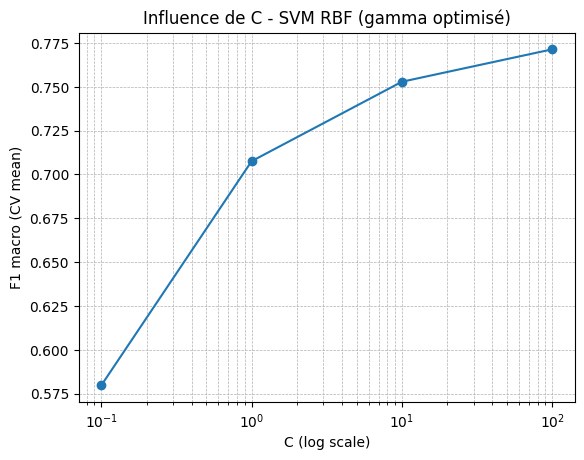

Meilleur gamma choisi par C (RBF):
       C  gamma  f1_macro_cv_mean
0    0.1  scale          0.579683
1    1.0    0.1          0.707561
2   10.0   0.01          0.752882
3  100.0   0.01          0.771379


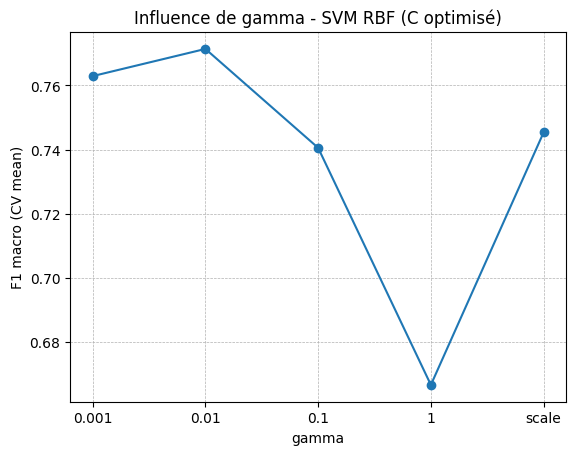

Meilleur C choisi par gamma (RBF):
   gamma      C  f1_macro_cv_mean
0  0.001  100.0          0.762902
1   0.01  100.0          0.771379
2    0.1   10.0          0.740519
3      1  100.0          0.666570
4  scale   10.0          0.745326


In [26]:
# -------------------------
# 2) GridSearch RBF (C + gamma) + extraction courbes
# -------------------------
param_grid_rbf = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

grid_rbf = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf"))]),
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

grid_rbf.fit(X_train, y_train)

# DataFrame des résultats CV
cv_df = pd.DataFrame(grid_rbf.cv_results_)

# Garder seulement les colonnes utiles
cv_df = cv_df[["param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score"]].copy()
cv_df.rename(columns={
    "param_svc__C": "C",
    "param_svc__gamma": "gamma",
    "mean_test_score": "f1_macro_cv_mean",
    "std_test_score": "f1_macro_cv_std"
}, inplace=True)

# -------------------------
# 2a) Influence de C pour RBF (meilleur gamma pour chaque C)
# -------------------------
best_by_C = cv_df.sort_values("f1_macro_cv_mean", ascending=False).groupby("C", as_index=False).first()
best_by_C = best_by_C.sort_values("C")

plt.figure()
plt.plot(best_by_C["C"], best_by_C["f1_macro_cv_mean"], marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("F1 macro (CV mean)")
plt.title("Influence de C - SVM RBF (gamma optimisé)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

print("Meilleur gamma choisi par C (RBF):")
print(best_by_C[["C", "gamma", "f1_macro_cv_mean"]])

# -------------------------
# 2b) Influence de gamma pour RBF (meilleur C pour chaque gamma)
# -------------------------
best_by_gamma = cv_df.sort_values("f1_macro_cv_mean", ascending=False).groupby("gamma", as_index=False).first()

# Pour gamma, si tu as "scale", c'est catégoriel -> on garde l'ordre défini
gamma_order = [0.001, 0.01, 0.1, 1, "scale"]
best_by_gamma["gamma"] = pd.Categorical(best_by_gamma["gamma"], categories=gamma_order, ordered=True)
best_by_gamma = best_by_gamma.sort_values("gamma")

plt.figure()
plt.plot(best_by_gamma["gamma"].astype(str), best_by_gamma["f1_macro_cv_mean"], marker="o")
plt.xlabel("gamma")
plt.ylabel("F1 macro (CV mean)")
plt.title("Influence de gamma - SVM RBF (C optimisé)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

print("Meilleur C choisi par gamma (RBF):")
print(best_by_gamma[["gamma", "C", "f1_macro_cv_mean"]])

In [18]:
for name, model in [("Linear", best_linear), ("RBF", best_rbf)]:
    y_pred = model.predict(X_test)
    print(name,
          "Accuracy:", accuracy_score(y_test, y_pred),
          "F1-macro:", f1_score(y_test, y_pred, average="macro"))


Linear Accuracy: 0.869 F1-macro: 0.7679880613922344
RBF Accuracy: 0.858 F1-macro: 0.7346154358400169


In [17]:
final_model = best_linear 

y_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion:\n", cm)

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
classes = np.unique(y_test)
for i, c_true in enumerate(classes):
    for j, c_pred in enumerate(classes):
        if i != j and cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], c_true, c_pred))

pairs_sorted = sorted(pairs, reverse=True)[:5]
print("\nTop confusions (nb, vrai -> prédit):")
for n, t, p in pairs_sorted:
    print(f"{n} : {t} -> {p}")


Matrice de confusion:
 [[518  51   0]
 [ 32 322  17]
 [  0  31  29]]

Top confusions (nb, vrai -> prédit):
51 : 0 -> 1
32 : 1 -> 0
31 : 2 -> 1
17 : 1 -> 2
